I have merged and cleaned the data. Now i want to perform an EDA to see what misses, what i can fill or delete and proceed to add the NACE column

## ***Initials***

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

## ***Load the Data***

In [50]:
df = pd.read_csv("cleaned-forsquare_xrysosOdigos_greekCatalog_vacationRenter.csv")
print(len(df))
df.head()

3906


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN)
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.76,"Retail sale of flowers, plants, seeds, fertili..."
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.59,"Retail sale of furniture, lighting equipment a..."
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,94.91,Activities of religious organisations
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,49.41,Freight transport by road
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...


# ***1. General Overview***

In [32]:
print("Shape:", df.shape, "\n")
print("Columns:", df.columns.tolist(), "\n")
df.info()  # Null counts and dtypes

Shape: (3906, 14) 

Columns: ['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country', 'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description', 'NACE Code', 'NACE Description (EN)'] 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3906 entries, 0 to 3905
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   3906 non-null   object 
 1   Category               3906 non-null   object 
 2   Latitude               3906 non-null   float64
 3   Longitude              3906 non-null   float64
 4   Address                3906 non-null   object 
 5   Country                3906 non-null   object 
 6   City                   3906 non-null   object 
 7   Postal Code            3906 non-null   int64  
 8   Rating                 246 non-null    object 
 9   Reviews                213 non-null    float64
 10  Source                 3906 non-null   object 
 11  Descri

# ***2. Missing Data Analysis***

Description              3715
Reviews                  3693
Rating                   3660
Name                        0
Category                    0
Latitude                    0
Longitude                   0
Address                     0
Country                     0
City                        0
Postal Code                 0
Source                      0
NACE Code                   0
NACE Description (EN)       0
dtype: int64


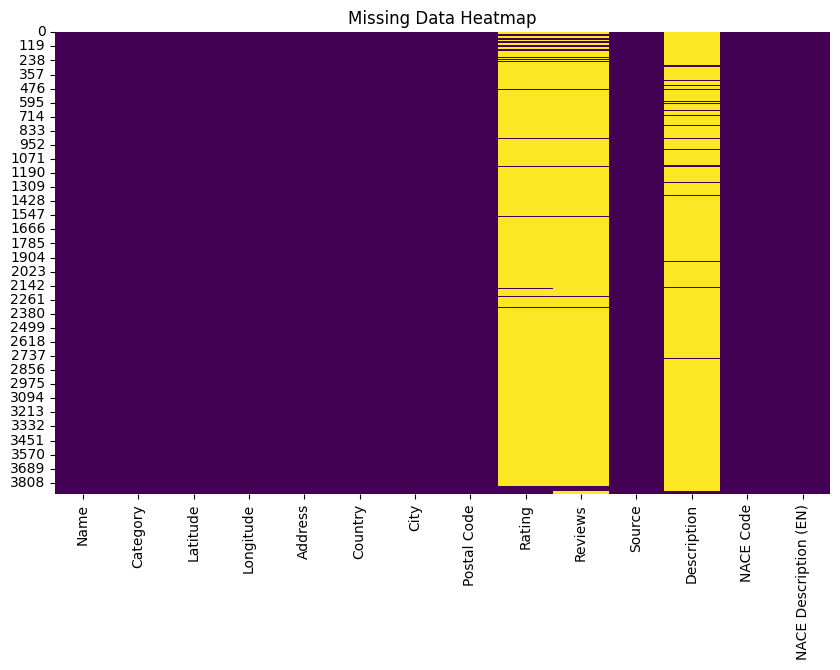

In [33]:
# Count missing values
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

# Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

All of the entries with null coordinates are a ***subset*** of the entries with no address --> if i do not have the address i have nothing

In [6]:
# i used this on the dataset before deleting the entries with missing address
no_address_df = df[df['Address'].isna()]
no_address_df.head(10)
no_address_df.to_csv("no_address.csv", index=False)

Since there are 390 entries that have no address, i decided to just ***drop*** them in order to not perform another manual search. This means that ***all*** the remaining data have address/lat/long features, and 14 of them do not have a zip. I can find this manually.

In [7]:
# Keep only rows where all three are present
df = df[
    df['Address'].notna() &
    df['Latitude'].notna() &
    df['Longitude'].notna()
]

In [8]:
len(df)

3906

In [15]:
df.to_csv("final_cleaned_volos_with_coordinates.csv", index=False)

## ***Feature: 'City'***

There are 24 features that do not have a city name, i can add it manually the common name "Βόλος Μαγνησίας".

In [9]:
no_city_df = df[df['City'].isna()]
print(len(no_city_df))
no_city_df.head(30)

0


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN)


In [30]:
df['City'] = df['City'].fillna('Βόλος Μαγνησίας')

In [32]:
df.to_csv("cleaned-forsquare_xrysosOdigos_greekCatalog_vacationRenter.csv", index=False)

## ***Feature: 'Postal Code'***

I had 14 entries with no postal code, and i filled them manually

I also wish to add demographic/economic data columns to the dataset later. In order to do this, i want to firstly inspect the feature 'Postal Code' in order to see the distribution of the zip codes used. Maybe they are very few and their use to gain further information is minimal.

In [39]:
df["Postal Code"] = df["Postal Code"].str.replace(" ", "")  # Remove spaces

AttributeError: Can only use .str accessor with string values!

Unique postal codes:  14
Postal Code
37011       1
37009       1
37500       2
38001       4
38223      59
37400      71
37300      96
38500     109
38445     176
38222     222
38446     286
38334     555
38333     815
38221    1509
Name: count, dtype: int64


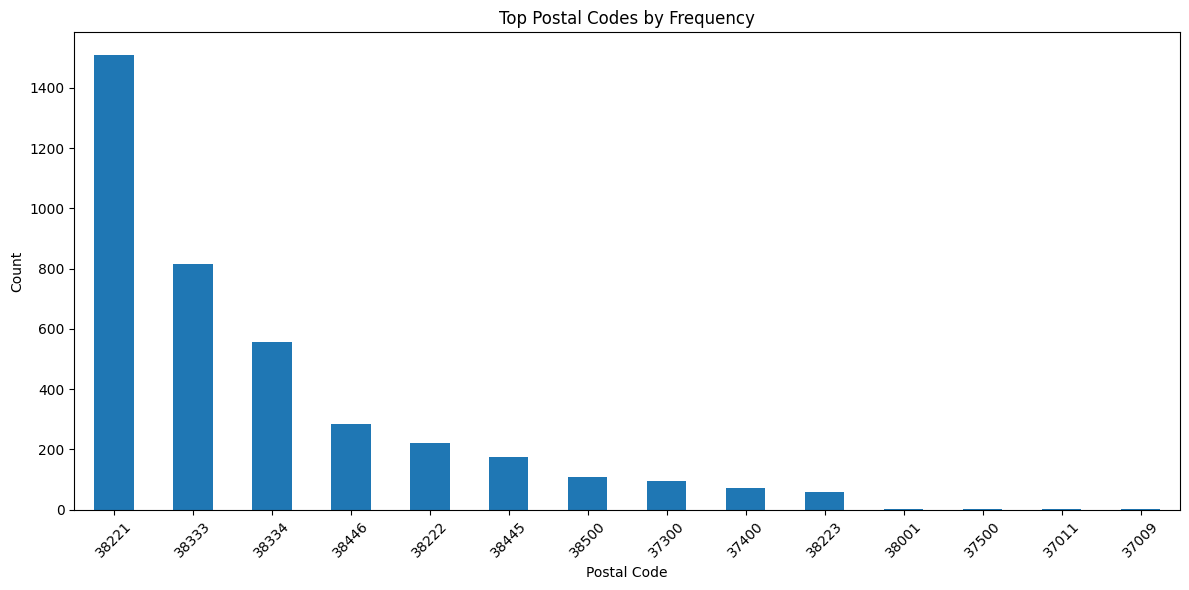

In [51]:
# Count the frequency of each postal code
postal_counts = df["Postal Code"].value_counts().sort_values()
print(f"Unique postal codes: ", len(postal_counts))
print(postal_counts)

# Plot top N most common postal codes
top_n = 20  # or another number based on how many are meaningful
df["Postal Code"].value_counts().head(top_n).plot(kind='bar', figsize=(12,6))
plt.title("Top Postal Codes by Frequency")
plt.xlabel("Postal Code")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
df.to_csv("cleaned-forsquare_xrysosOdigos_greekCatalog_vacationRenter.csv", index=False)

## ***Feature: 'Category'***

There are 4 entries that do not contain a category name, i can search for it and add it manually

In [10]:
no_category_df = df[df['Category'].isna()]
print(len(no_category_df))
no_category_df.head(30)

0


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN)
